"F:\Jupyter Projects\Phitron AL ML\Dataset\Titanic-Dataset.csv"

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats 

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import TargetEncoder

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import MaxAbsScaler

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv("F:\Jupyter Projects\Phitron AL ML\Dataset\Titanic-Dataset.csv")
df

<>:1: SyntaxWarning: invalid escape sequence '\J'
<>:1: SyntaxWarning: invalid escape sequence '\J'
C:\Users\HP\AppData\Local\Temp\ipykernel_16724\1059932931.py:1: SyntaxWarning: invalid escape sequence '\J'
  df = pd.read_csv("F:\Jupyter Projects\Phitron AL ML\Dataset\Titanic-Dataset.csv")


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


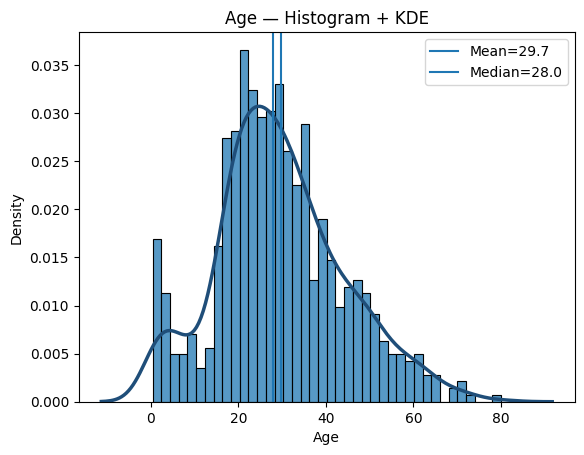

In [8]:
sns.histplot(df['Age'], bins=40,  stat='density') 
sns.kdeplot(df['Age'], linewidth=2.5, color='#1F4E79') 
plt.axvline(df['Age'].mean(), 
label=f"Mean={df['Age'].mean():.1f}") 
plt.axvline(df['Age'].median(),  
label=f"Median={df['Age'].median():.1f}") 
plt.legend(); plt.title('Age — Histogram + KDE'); plt.show() 

In [9]:
# skewness ও kurtosis পচরমাপ 
print(df['Age'].skew())          # 0.40  → হালকা right-skewed 
print(df['Fare'].skew())         # 4.79  → প্র্বল right-skewed 
  
print(df['Age'].kurtosis())      # 0.17  → mesokurtic (normal-এর কাছাকাচছ) 
print(df['Fare'].kurtosis())     # 33.4  → leptokurtic (িারী ট্রলজ, extreme outlier) 

0.38910778230082704
4.787316519674893
0.17827415364210353
33.39814088089868


In [10]:
df[['Age','Fare','SibSp','Parch']].agg(['skew','kurtosis']) 

,Age,Fare,SibSp,Parch
skew,0.389108,4.787317,3.695352,2.749117
kurtosis,0.178274,33.398141,17.880420,9.778125


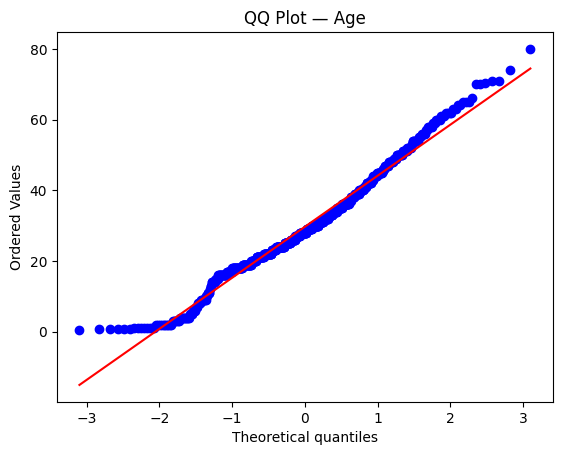

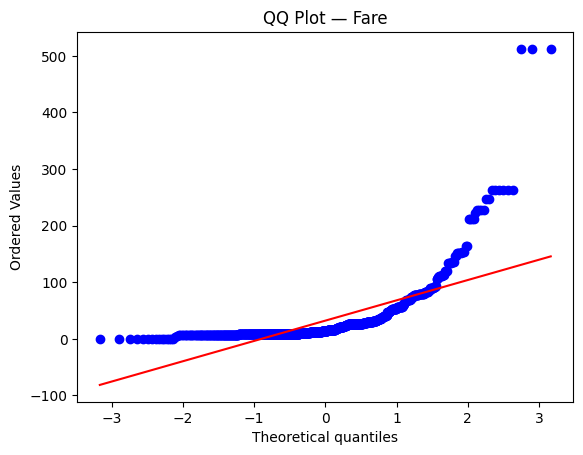

In [14]:
stats.probplot(df['Age'].dropna(), dist='norm', plot=plt) 
plt.title('QQ Plot — Age'); plt.show() 
# Fare — QQ Plot 
stats.probplot(df['Fare'], dist='norm', plot=plt)
plt.title('QQ Plot — Fare'); plt.show() 

In [15]:
corr, p_value = stats.pointbiserialr(
    df['Survived'],
    df['Age'].fillna(df['Age'].median())
)

print(f'Point-Biserial r = {corr:.3f}, p-value = {p_value:.4f}')


Point-Biserial r = -0.065, p-value = 0.0528
